In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

we will treat zero blood pressure and cholesterol readings as missing, match it with the clean values from the eda.

In [2]:
df_clean = pd.read_csv("Heart_dataset")
df_clean = df_clean.replace([" ", "NA", "N/A", ""], np.nan)

for column in ["RestingBP", "Cholesterol"]:
    if column in df_clean.columns:
        df_clean[column] = pd.to_numeric(df_clean[column], errors="coerce")
        df_clean[column] = df_clean[column].replace(0, np.nan)

print("Dataset shape:", df_clean.shape)
display(df_clean.head())
print("\nMissing values by column:")
display(df_clean.isna().sum())

Dataset shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0



Missing values by column:


Age                 0
Sex                 0
ChestPainType       0
RestingBP           1
Cholesterol       172
FastingBS           0
RestingECG          0
MaxHR               0
ExerciseAngina      0
Oldpeak             0
ST_Slope            0
HeartDisease        0
dtype: int64

HeartDisease is what the models will predict. All other columns are features used to make the prediction.

In [3]:
target_column = "HeartDisease"

X = df_clean.drop(columns=[target_column])
y = df_clean[target_column]

if y.isna().any():
    raise ValueError("The target column contains missing values. Clean it before training.")

print("Feature columns:", list(X.columns))
print("\nTarget values:")
print(y.value_counts().sort_index())

Feature columns: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']

Target values:
HeartDisease
0    410
1    508
Name: count, dtype: int64


## USING TRAIN-TEST-SPLIT 
TRAINING:70-TESTING-30

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.30,random_state=42,stratify=y)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 642
Testing rows: 276


## preprocessing
numerical features are standardized.
categorical features have the most frequesnt training value.


In [5]:
numeric_columns = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_columns = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_preprocessing = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_preprocessing = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("one_hot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_preprocessing, numeric_columns),
    ("categorical", categorical_preprocessing, categorical_columns),
])

print("Numeric columns:", numeric_columns)
print("Categorical columns:", categorical_columns)

Numeric columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
Categorical columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


### For each model, the function fits the model on the training data and evaluates predictions on the testing data. It prints accuracy, a classification report, and a confusion matrix.

code for evaulation function:

In [6]:
def evaluate_model(model, model_name, threshold=None):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    if threshold is not None:
        predictions = (predictions >= threshold).astype(int)

    labels = sorted(y.unique())
    accuracy = accuracy_score(y_test, predictions)

    print(f"\n{model_name}")
    print(f"Accuracy: {accuracy:.4f} ({accuracy:.2%})")
    print("\nClassification report:")
    print(classification_report(
        y_test,
        predictions,
        labels=labels,
        zero_division=0,
    ))
    print("Confusion matrix (rows = actual, columns = predicted):")
    print(confusion_matrix(y_test, predictions, labels=labels))

    label_names = ["Not diseased", "Diseased"]
    matrix = confusion_matrix(y_test, predictions, labels=labels)
    ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=label_names,
    ).plot(cmap="Blues", values_format="d")
    plt.title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    plt.show()
    
    return accuracy

Logistic Regression is designed for classification. It estimates the probability of each class and predicts the most likely class.


Logistic Regression
Accuracy: 0.8804 (88.04%)

Classification report:
              precision    recall  f1-score   support

           0       0.87      0.86      0.87       123
           1       0.89      0.90      0.89       153

    accuracy                           0.88       276
   macro avg       0.88      0.88      0.88       276
weighted avg       0.88      0.88      0.88       276

Confusion matrix (rows = actual, columns = predicted):
[[106  17]
 [ 16 137]]


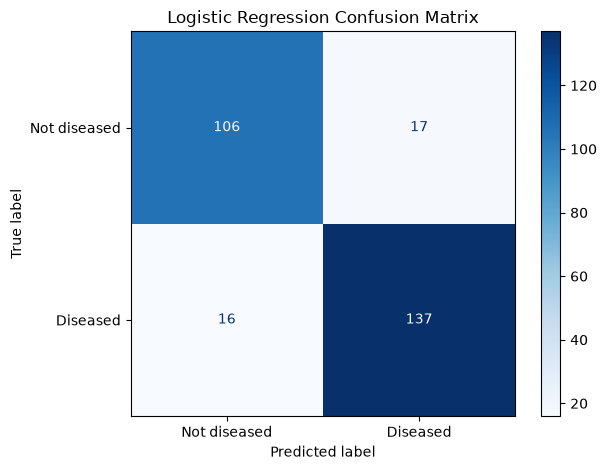

In [7]:
logistic_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=42)),
])

logistic_accuracy = evaluate_model(
    logistic_pipeline,
    "Logistic Regression",
)

Linear Regression is designed to predict continuous values, not classes. For this comparison, we convert each prediction to class 1 if it is at least 0.5, otherwise class 0.


Linear Regression (0.5 threshold)
Accuracy: 0.8804 (88.04%)

Classification report:
              precision    recall  f1-score   support

           0       0.87      0.86      0.87       123
           1       0.89      0.90      0.89       153

    accuracy                           0.88       276
   macro avg       0.88      0.88      0.88       276
weighted avg       0.88      0.88      0.88       276

Confusion matrix (rows = actual, columns = predicted):
[[106  17]
 [ 16 137]]


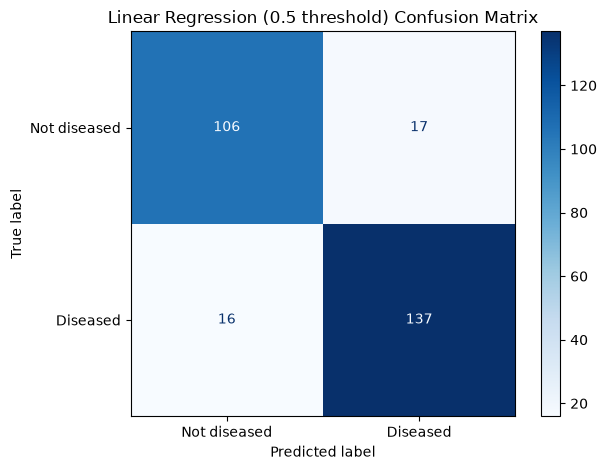

In [8]:
linear_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LinearRegression()),
])

linear_accuracy = evaluate_model(
    linear_pipeline,
    "Linear Regression (0.5 threshold)",
    threshold=0.5,
)

### Comparing the test-set accuracy from both models.

In [9]:
print("Accuracy comparison:")
print(f"Logistic Regression: {logistic_accuracy:.4f} ({logistic_accuracy:.2%})")
print(f"Linear Regression:   {linear_accuracy:.4f} ({linear_accuracy:.2%})")

if logistic_accuracy > linear_accuracy:
    print("\nBetter accuracy on this test split: Logistic Regression")
elif linear_accuracy > logistic_accuracy:
    print("\nBetter accuracy on this test split: Linear Regression")
else:
    print("\nBoth models have the same accuracy on this test split.")

Accuracy comparison:
Logistic Regression: 0.8804 (88.04%)
Linear Regression:   0.8804 (88.04%)

Both models have the same accuracy on this test split.
